# Why Heat-Gated Fourier Features?

This notebook tests empirically the formula outlined in the README.md

1. We test empirically the spectral bias of MLPs and argue and test that while Fourier Features can address it, the way you choose the frequencies matter. We compare raw coordinates vs. RFF vs. `HeatGatedFourierFeatures`.

2. While at `t=0` the tiles' boundaries are sharp, Gaussian blurring acts as ... which ... . Thus, at high-noise regime, the spectral bias is less of an issue and fixed `HeatGatedFourierFeatures` can be counterproductive when using the same network conditionned on noise level.

In [ ]:
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from scipy.ndimage import gaussian_filter

sys.path.insert(0, str(Path.cwd().parent))
from models.mlp import HeatGatedFourierFeatures, SinusoidalTimeEmbedding

torch.manual_seed(42)
np.random.seed(42)

## 1. Raw coordinates vs. Gaussian RFF vs. `HeatGatedFourierFeatures`

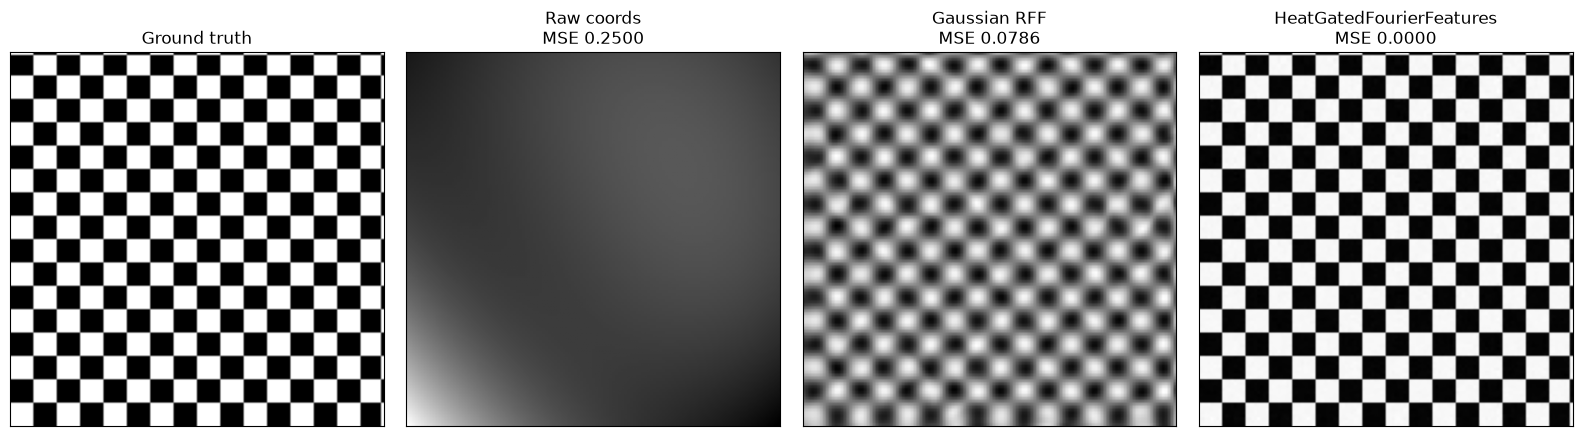

In [ ]:
grid_res = 128
num_tiles = 16
coords_t = torch.linspace(-1, 1, grid_res)
xg, yg = torch.meshgrid(coords_t, coords_t, indexing="xy")
tile_x_t = torch.floor((xg + 1.0) / (2.0 / num_tiles)).long()
tile_y_t = torch.floor((yg + 1.0) / (2.0 / num_tiles)).long()
target_density = ((tile_x_t + tile_y_t) % 2 == 0).float()

X_pts_t = torch.stack([xg.flatten(), yg.flatten()], dim=-1)
y_pts = target_density.flatten().unsqueeze(-1)

class GaussianRFF(nn.Module):
    """Naive isotropic RFF"""
    def __init__(self, dim=2, num_features=128, sigma=6.0):
        super().__init__()
        self.register_buffer("freqs", torch.randn(num_features, dim) * sigma)
        self.register_buffer("phases", torch.rand(num_features) * 2 * math.pi)
        self.scale = math.sqrt(2.0 / num_features)
        self.num_features = num_features

    def forward(self, x):
        return torch.cos(x @ self.freqs.T + self.phases) * self.scale

class TinyMLP(nn.Module):
    def __init__(self, in_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x)

def train_and_eval(feat_fn, in_dim, steps=1000, lr=1e-2):
    torch.manual_seed(42)
    model = TinyMLP(in_dim)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        loss = nn.functional.mse_loss(model(feat_fn()), y_pts)
        loss.backward()
        opt.step()
    with torch.no_grad():
        pred = model(feat_fn()).reshape(grid_res, grid_res).numpy()
    return pred, loss.item()

heatgated = HeatGatedFourierFeatures(dim=2, n_tiles=num_tiles, num_features=128, num_harmonics=16.0)
zero_sigma = torch.zeros(X_pts_t.shape[0])  # no noise here -> gating fully open
gauss = GaussianRFF()

pred_raw, loss_raw = train_and_eval(lambda: X_pts_t, in_dim=2)
pred_gauss, loss_gauss = train_and_eval(lambda: gauss(X_pts_t), in_dim=gauss.num_features)
pred_heat, loss_heat = train_and_eval(lambda: heatgated(X_pts_t, zero_sigma), in_dim=heatgated.num_features)

fig, axs = plt.subplots(1, 4, figsize=(16, 4.2))
axs[0].imshow(target_density.numpy(), cmap="gray", origin="lower"); axs[0].set_title("Ground truth")
axs[1].imshow(pred_raw, cmap="gray", origin="lower"); axs[1].set_title(f"Raw coords\nMSE {loss_raw:.4f}")
axs[2].imshow(pred_gauss, cmap="gray", origin="lower"); axs[2].set_title(f"Gaussian RFF\nMSE {loss_gauss:.4f}")
axs[3].imshow(pred_heat, cmap="gray", origin="lower"); axs[3].set_title(f"HeatGatedFourierFeatures\nMSE {loss_heat:.4f}")
for ax in axs:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 2. Is Gating Necessary?

In [4]:
grid_res = 128
num_tiles = 16
coords_np = np.linspace(-1, 1, grid_res)
xg_np, yg_np = np.meshgrid(coords_np, coords_np, indexing="xy")
tile_x_np = np.floor((xg_np + 1.0) / (2.0 / num_tiles)).astype(int)
tile_y_np = np.floor((yg_np + 1.0) / (2.0 / num_tiles)).astype(int)
clean_target = ((tile_x_np + tile_y_np) % 2 == 0).astype(np.float32)

pixel_scale = grid_res / 2.0
sigmas = [0.0, 0.08, 0.35]
regime_names = ["sigma=0.00 (clean)", "sigma=0.08 (small noise)", "sigma=0.35 (high noise)"]
targets = [clean_target] + [
    gaussian_filter(clean_target, sigma=s * pixel_scale, mode="reflect") for s in sigmas[1:]
]

X_pts_np = torch.tensor(np.stack([xg_np.ravel(), yg_np.ravel()], axis=-1), dtype=torch.float32)
N_pts = X_pts_np.shape[0]
y_tensors = [torch.tensor(t.ravel()[:, None], dtype=torch.float32) for t in targets]

### 2a. Independent model per noise level

We see that when using independent model per noise level, gating is pretty much useless and can even make optimization harder.

In [5]:
def fit_regime(target_y, sigma_val, gated, steps=800, lr=1e-2):
    torch.manual_seed(42)
    encoder = HeatGatedFourierFeatures(dim=2, n_tiles=num_tiles, num_features=128, num_harmonics=16.0)
    sigma_batch = torch.full((N_pts,), sigma_val if gated else 0.0)
    feat = encoder(X_pts_np, sigma_batch)
    model = TinyMLP(encoder.num_features)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        loss = nn.functional.mse_loss(model(feat), target_y)
        loss.backward()
        opt.step()
    return loss.item()

print(f"{'regime':28s} {'ungated MSE':>12s} {'gated MSE':>12s}")
for i, name in enumerate(regime_names):
    mse_ungated = fit_regime(y_tensors[i], sigmas[i], gated=False)
    mse_gated = fit_regime(y_tensors[i], sigmas[i], gated=True)
    print(f"{name:28s} {mse_ungated:12.5f} {mse_gated:12.5f}")

regime                        ungated MSE    gated MSE
sigma=0.00 (clean)                0.00004      0.00004
sigma=0.08 (small noise)          0.00000      0.00004
sigma=0.35 (high noise)           0.00000      0.00000


### 2b. One shared MLP conditioned on sigma

When leveraging a share MLP conditioned on sigma (what we do in diffusion and flow matching models), gating improves training.

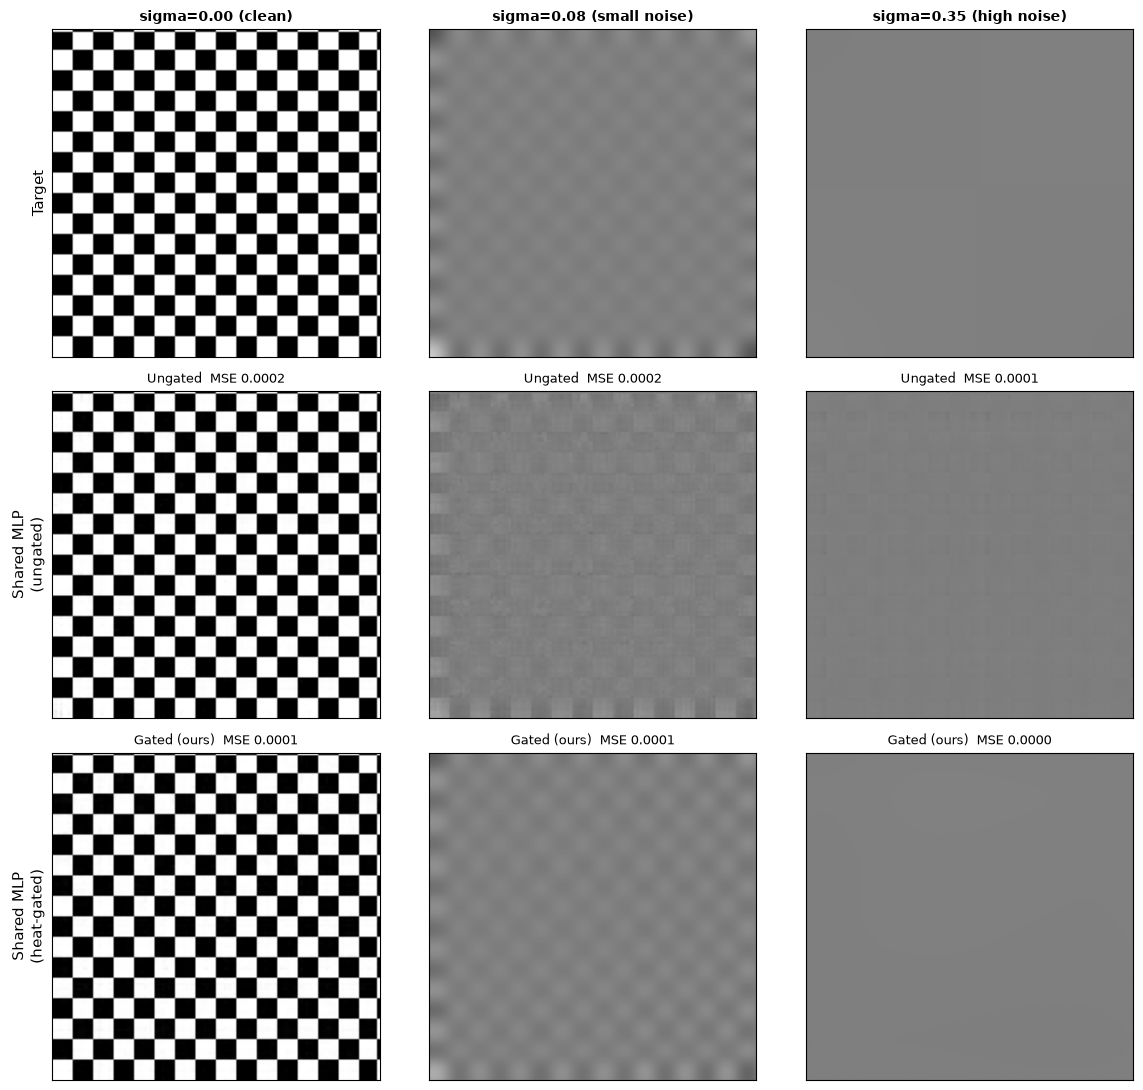


Mean MSE across regimes -- ungated: 0.00014   gated: 0.00008


In [6]:
class SharedConditionalMLP(nn.Module):
    def __init__(self, num_features=128, time_dim=32, hidden_dim=128, n_tiles=16, use_gating=True):
        super().__init__()
        self.use_gating = use_gating
        self.time_embed = SinusoidalTimeEmbedding(time_dim)
        self.spatial_embed = HeatGatedFourierFeatures(
            dim=2, n_tiles=n_tiles, num_features=num_features, num_harmonics=16.0
        )
        self.net = nn.Sequential(
            nn.Linear(self.spatial_embed.num_features + time_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x, sigma):
        sigma_in = sigma if self.use_gating else torch.zeros_like(sigma)
        x_emb = self.spatial_embed(x, sigma_in)
        t_emb = self.time_embed(sigma)
        return self.net(torch.cat([x_emb, t_emb], dim=-1))

def train_shared(use_gating, steps=2000, lr=5e-3):
    torch.manual_seed(42)
    model = SharedConditionalMLP(use_gating=use_gating, n_tiles=num_tiles)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(steps):
        task = np.random.randint(0, 3)
        sigma_batch = torch.full((N_pts,), sigmas[task])
        opt.zero_grad()
        loss = nn.functional.mse_loss(model(X_pts_np, sigma_batch), y_tensors[task])
        loss.backward()
        opt.step()

    model.eval()
    preds, losses = [], []
    with torch.no_grad():
        for i in range(3):
            sigma_batch = torch.full((N_pts,), sigmas[i])
            pred = model(X_pts_np, sigma_batch)
            losses.append(nn.functional.mse_loss(pred, y_tensors[i]).item())
            preds.append(pred.reshape(grid_res, grid_res).numpy())
    return preds, losses

preds_ungated, losses_ungated = train_shared(use_gating=False)
preds_gated, losses_gated = train_shared(use_gating=True)

fig, axs = plt.subplots(3, 3, figsize=(12, 11))
for col in range(3):
    axs[0, col].imshow(targets[col], cmap="gray", origin="lower", vmin=0, vmax=1)
    axs[0, col].set_title(regime_names[col], fontsize=10, fontweight="bold")
    axs[1, col].imshow(preds_ungated[col], cmap="gray", origin="lower", vmin=0, vmax=1)
    axs[1, col].set_title(f"Ungated  MSE {losses_ungated[col]:.4f}", fontsize=9)
    axs[2, col].imshow(preds_gated[col], cmap="gray", origin="lower", vmin=0, vmax=1)
    axs[2, col].set_title(f"Gated (ours)  MSE {losses_gated[col]:.4f}", fontsize=9)
axs[0, 0].set_ylabel("Target", fontsize=11)
axs[1, 0].set_ylabel("Shared MLP\n(ungated)", fontsize=11)
axs[2, 0].set_ylabel("Shared MLP\n(heat-gated)", fontsize=11)
for ax in axs.flat:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

print(f"\nMean MSE across regimes -- ungated: {np.mean(losses_ungated):.5f}   gated: {np.mean(losses_gated):.5f}")